# Chapter 11 - Logistic Regression

In the earlier chapters, we used regression models to predict continuous values. In this chapter, we move from regression to classification.

Logistic Regression first calculates a weighted sum of the input features, then passes that score through the sigmoid function to convert it into a probability between 0 and 1.

If the probability is greater than or equal to 0.5, the model predicts class 1. Otherwise, it predicts class 0.

Logistic Regression is used when the output is categorical. 

Here, we will predict whether a student is placed or not placed using IQ and CGPA, then extend the idea to regularization, non-linear data, and multi-class classification.


## Step 1 - Import Required Libraries

Firstly, we import the libraries required for data loading, visualization, model building, model evaluation, regularization experiments, and decision-boundary plotting.

In [1]:
# import all the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.plotting import plot_decision_regions
from sklearn.datasets import make_classification, make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

RANDOM_STATE = 42
plt.style.use("default")

## Step 2 - Data Ingestion

We use a simple student placement dataset.

In [2]:
# load the student placement dataset from the official chapter repository
students_url = "https://raw.githubusercontent.com/kanetkar/LULML/refs/heads/main/ch11/students.csv"

df = pd.read_csv(students_url)

print("Dataset shape:", df.shape)

print("\nFirst five rows:")
print(df.head())

Dataset shape: (100, 3)

First five rows:
           IQ      CGPA  Placed
0  116.521863  7.839804       1
1  111.114991  7.230805       1
2  109.839861  7.253657       1
3   99.772056  5.960763       0
4  111.693979  9.576941       1


The first inspection shows three important columns:

- IQ: the student's IQ score
- CGPA: the student's academic performance
- Placed: the target column, where 1 means placed and 0 means not placed

Before model building, we check the dataset structure and missing values. This confirms whether the data is ready for direct modelling.

In [3]:
# inspect columns and missing values before model building
print("Columns in the dataset:")
print(df.columns.tolist())

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["Placed"].value_counts())

Columns in the dataset:
['IQ', 'CGPA', 'Placed']

Missing values in each column:
IQ        0
CGPA      0
Placed    0
dtype: int64

Class distribution:
Placed
1    50
0    50
Name: count, dtype: int64


The output tells us that both classes have equal distribution in the dataset and no preprocessing is needed before training Logistic Regression.

## Step 3 - Exploratory Data Analysis

Now we visualize IQ and CGPA against the placement label. This helps us see whether the two classes can be separated by a straight boundary.

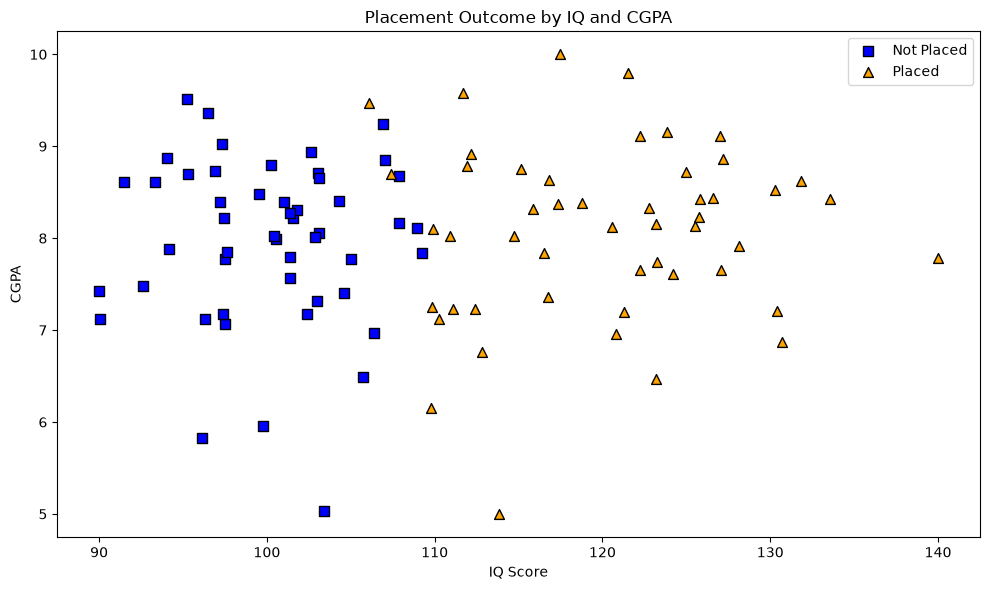

In [4]:
# scatter plot to showcase relationship between IQ, CGPA, and placement
plt.figure(figsize=(10, 6))

plt.scatter(
    df[df.Placed == 0]["IQ"],
    df[df.Placed == 0]["CGPA"],
    c="blue",
    marker="s",
    label="Not Placed",
    edgecolor="k",
    s=50,
)

plt.scatter(
    df[df.Placed == 1]["IQ"],
    df[df.Placed == 1]["CGPA"],
    c="orange",
    marker="^",
    label="Placed",
    edgecolor="k",
    s=50,
)

plt.xlabel("IQ Score")
plt.ylabel("CGPA")
plt.title("Placement Outcome by IQ and CGPA")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

The scatter plot shows how the two classes are arranged in the IQ-CGPA space. 

Since the classes are mostly separable by a straight line, Logistic Regression is a reasonable starting model.

## Step 4 - Prepare Features and Target

Now we separate the input columns from the output column. The model will learn from IQ and CGPA, and it will try to predict the placement label.

In [5]:
# features columns
X = df[["IQ", "CGPA"]]

# target column
y = df["Placed"]

print("Feature preview:")
print(X.head())

print("\nTarget preview:")
print(y.head())

Feature preview:
           IQ      CGPA
0  116.521863  7.839804
1  111.114991  7.230805
2  109.839861  7.253657
3   99.772056  5.960763
4  111.693979  9.576941

Target preview:
0    1
1    1
2    1
3    0
4    1
Name: Placed, dtype: int64


We split the data into training and testing sets. The model learns from the training set, and we judge its performance on the test set.

In [6]:
# split the dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 80
Testing rows: 20


## Step 5 - Train the Logistic Regression Model

Logistic Regression is used here because the output is binary: placed or not placed. The model learns a decision boundary between the two classes.

In [7]:
# create Logistic Regression model
placement_model = LogisticRegression()

# train the model on training data
placement_model.fit(X_train, y_train)

print("Model coefficients:", placement_model.coef_)
print("Model intercept:", placement_model.intercept_)

Model coefficients: [[0.95955916 0.1843429 ]]
Model intercept: [-105.3096774]


The coefficients are the learned weights for IQ and CGPA. These weights decide how strongly each feature influences the final placement probability.

## Step 6 - Model Evaluation

After training, we use the model to predict labels for the test set and calculate accuracy.

In [8]:
# make predictions on the test set
y_pred = placement_model.predict(X_test)

# measure accuracy of the Logistic Regression model
acc = accuracy_score(y_test, y_pred)

print(f"Model Accuracy on Test Set: {acc * 100:.2f}%")

Model Accuracy on Test Set: 95.00%


The accuracy tells us what percentage of test examples were classified correctly by the trained Logistic Regression model.

We can also inspect predicted probabilities. This shows the probability assigned to each class before the final 0 or 1 decision is made.

In [9]:
# preview predicted probabilities before final class prediction
probability_preview = pd.DataFrame(
    placement_model.predict_proba(X_test[:5]),
    columns=["Probability_Not_Placed", "Probability_Placed"],
    index=X_test[:5].index,
)

print("Predicted probabilities for first five test rows:")
print(probability_preview)

print("\nFinal predicted classes:")
print(y_pred[:5])

Predicted probabilities for first five test rows:
    Probability_Not_Placed  Probability_Placed
83            5.090879e-10        1.000000e+00
53            6.031739e-08        9.999999e-01
70            1.000000e+00        2.294639e-08
45            1.084700e-08        1.000000e+00
44            2.752214e-01        7.247786e-01

Final predicted classes:
[1 1 0 1 1]


The probability values explain the prediction decision. If the probability for class 1 is higher than the threshold, the model predicts placed.

## Step 7 - Plot the Decision Boundary

The decision boundary is the line or surface that separates the predicted classes.

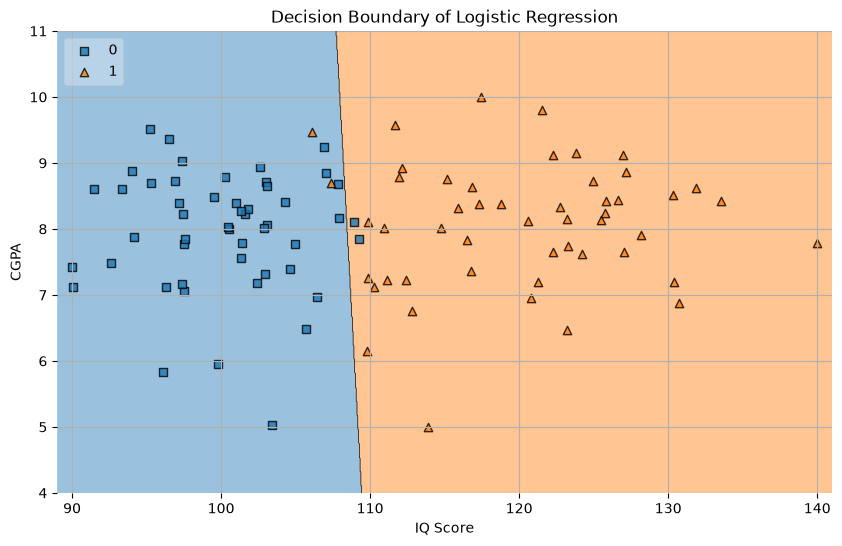

In [10]:
# convert data to numpy arrays because mlxtend expects numpy input
X_np = X.values
y_np = y.values

# retrain the model on full data only for visualization
boundary_model = LogisticRegression()
boundary_model.fit(X_np, y_np)

plt.figure(figsize=(10, 6))
plot_decision_regions(X_np, y_np, clf=boundary_model, legend=2)
plt.xlabel("IQ Score")
plt.ylabel("CGPA")
plt.title("Decision Boundary of Logistic Regression")
plt.grid(True)
plt.show()

The decision boundary shows how Logistic Regression separates placed and not placed students. 

Since Logistic Regression is linear in the original features, the boundary is a straight line.

## Step 8 - Logistic Regression in High-Dimensional Data

Real-world datasets often contain many features. In such cases, Logistic Regression may overfit by assigning importance to noisy or irrelevant features.

To demonstrate this, let's create a synthetic dataset with many columns but only a few truly informative features.

In [11]:
# generate a high-dimensional binary classification dataset
X_hd, y_hd = make_classification(
    n_samples=500,
    n_features=100,
    n_informative=5,
    n_redundant=0,
    n_classes=2,
    random_state=RANDOM_STATE,
)

print("High-dimensional feature matrix shape:", X_hd.shape)
print("Target shape:", y_hd.shape)

High-dimensional feature matrix shape: (500, 100)
Target shape: (500,)


This dataset has 100 features, but only 5 of them are informative. This creates a situation where overfitting can become a problem.

In [12]:
# split the high-dimensional dataset
X_hd_train, X_hd_test, y_hd_train, y_hd_test = train_test_split(
    X_hd, y_hd, test_size=0.2, random_state=1
)

print("Training shape:", X_hd_train.shape)
print("Testing shape:", X_hd_test.shape)

Training shape: (400, 100)
Testing shape: (100, 100)


First, we train Logistic Regression with almost no regularization. This helps us see how the model behaves when it is allowed to fit the data very freely.

In [13]:
# train model with very weak regularization
model_no_reg = LogisticRegression( C=1e10, max_iter=1000)
model_no_reg.fit(X_hd_train, y_hd_train)

# compare training and testing accuracy
train_acc_no_reg = accuracy_score(y_hd_train, model_no_reg.predict(X_hd_train))
test_acc_no_reg = accuracy_score(y_hd_test, model_no_reg.predict(X_hd_test))

print(f"Train Accuracy (no regularization): {train_acc_no_reg * 100:.2f}%")
print(f"Test Accuracy (no regularization): {test_acc_no_reg * 100:.2f}%")

Train Accuracy (no regularization): 93.25%
Test Accuracy (no regularization): 69.00%


Our model achieved 93.25% accuracy on the training set, but only 69.00% on the test set.

This large gap is a classic sign of overfitting. The model has learned the training data—including its noise—too well, but it fails to generalize to new, unseen examples.

## Step 9 - Use Elastic Net Regularization

Next, we'll see how regularization can help control this complexity and improve the model’s ability to generalize.

Elastic Net regularization combines L1 and L2 penalties. It helps reduce overfitting by discouraging overly large or unnecessary weights.
- We will use Elastic Net regularization with an l1_ratio of 0.5—meaning it will apply an equal mix of L1 (lasso) and L2 (ridge) penalties.


In [27]:
# train Logistic Regression with Elastic Net regularization
model_en = LogisticRegression(
    solver="saga",
    C=0.1,
    l1_ratio=0.5,
    max_iter=1000,
    random_state=RANDOM_STATE,
)
model_en.fit(X_hd_train, y_hd_train)

# compare training and testing accuracy after regularization
train_acc_en = accuracy_score(y_hd_train, model_en.predict(X_hd_train))
test_acc_en = accuracy_score(y_hd_test, model_en.predict(X_hd_test))

print(f"Elastic Net - Train Accuracy: {train_acc_en * 100:.2f}%")
print(f"Elastic Net - Test Accuracy: {test_acc_en * 100:.2f}%")

Elastic Net - Train Accuracy: 88.00%
Elastic Net - Test Accuracy: 85.00%


Elastic Net may slightly reduce training accuracy, but it can improve generalization by controlling model complexity.

## Step 10 - Logistic Regression on Non-Linear Data

Logistic Regression creates a linear decision boundary in the original feature space. If the data is non-linear, a straight line may not be enough.

Let's understand this via a simple demonstration.

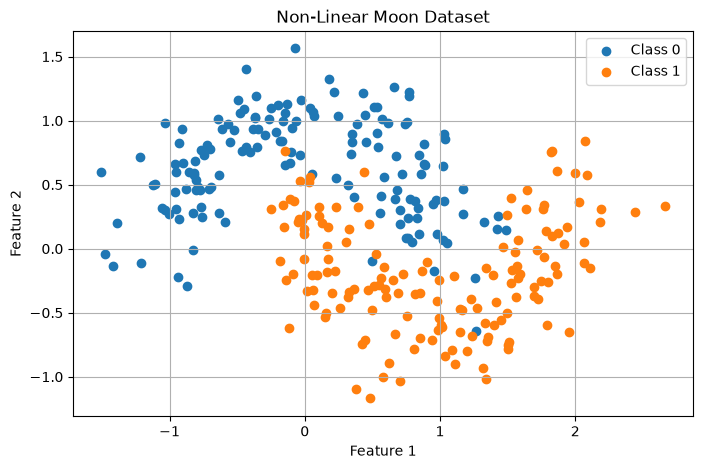

In [15]:
# generate non-linearly separable moon-shaped data
X_moon, y_moon = make_moons(n_samples=300, noise=0.25, random_state=0)

plt.figure(figsize=(8, 5))
plt.scatter(X_moon[y_moon == 0][:, 0], X_moon[y_moon == 0][:, 1], label="Class 0")
plt.scatter(X_moon[y_moon == 1][:, 0], X_moon[y_moon == 1][:, 1], label="Class 1")
plt.title("Non-Linear Moon Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

The two classes form curved moon shapes.

A straight decision boundary will struggle to separate them perfectly.

In [16]:
# train a baseline Logistic Regression model on non-linear data
X_moon_train, X_moon_test, y_moon_train, y_moon_test = train_test_split(
    X_moon, y_moon, test_size=0.2, random_state=RANDOM_STATE
)

moon_linear_model = LogisticRegression()
moon_linear_model.fit(X_moon_train, y_moon_train)

train_acc_moon_linear = accuracy_score(y_moon_train, moon_linear_model.predict(X_moon_train))
test_acc_moon_linear = accuracy_score(y_moon_test, moon_linear_model.predict(X_moon_test))

print(f"Train Accuracy: {train_acc_moon_linear * 100:.2f}%")
print(f"Test Accuracy: {test_acc_moon_linear * 100:.2f}%")

Train Accuracy: 82.08%
Test Accuracy: 85.00%


The baseline model is limited because it can only create a straight boundary. We now plot that boundary to see the limitation visually.

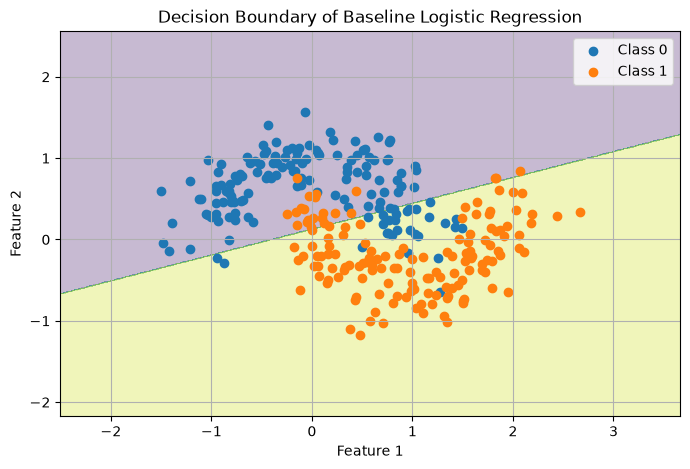

In [17]:
# helper function to plot decision boundary for two-feature data
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500),
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.figure(figsize=(8, 5))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label="Class 0")
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label="Class 1")
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_decision_boundary(
    moon_linear_model,
    X_moon,
    y_moon,
    "Decision Boundary of Baseline Logistic Regression",
)

As you can see the logistic regression model forms a linear decision boundary, which struggles to separate the non-linear "moons" dataset. 

As seen in the above plot, several points near the overlapping region are misclassified.

## Step 11 - Add Polynomial Features for Non-Linear Data

To make Logistic Regression work better on non-linear data, we can transform the input features into polynomial features and then train Logistic Regression on those transformed features.

In [18]:
# before polynomial transformation, the moon dataset has two input features
print("Before polynomial transformation:")
print(pd.DataFrame(X_moon_train[:5], columns=["feature_1", "feature_2"]))

Before polynomial transformation:
   feature_1  feature_2
0  -0.171804   0.844590
1  -0.161102   0.339050
2   1.412713  -0.414048
3  -0.476639   1.056452
4   0.534603   0.906916


In [19]:
# create a pipeline with polynomial features and Logistic Regression
moon_poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=3)),
    ("log_reg", LogisticRegression(max_iter=1000)),
])
moon_poly_model.fit(X_moon_train, y_moon_train)

train_acc_moon_poly = accuracy_score(y_moon_train, moon_poly_model.predict(X_moon_train))
test_acc_moon_poly = accuracy_score(y_moon_test, moon_poly_model.predict(X_moon_test))

print("After polynomial transformation, the model receives curved feature combinations internally.")
print(f"Train Accuracy: {train_acc_moon_poly * 100:.2f}%")
print(f"Test Accuracy: {test_acc_moon_poly * 100:.2f}%")

After polynomial transformation, the model receives curved feature combinations internally.
Train Accuracy: 94.58%
Test Accuracy: 91.67%


The polynomial transformation gives the model extra feature combinations. 

This allows Logistic Regression to create a curved decision boundary in the original input space.

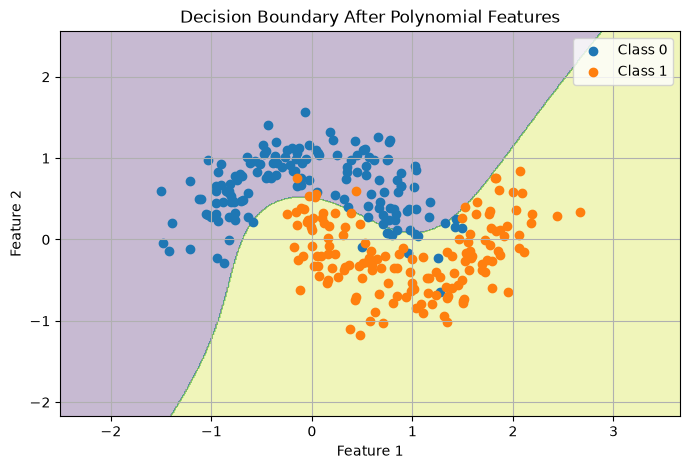

In [20]:
# plot decision boundary after polynomial feature transformation
plot_decision_boundary(
    moon_poly_model,
    X_moon,
    y_moon,
    "Decision Boundary After Polynomial Features",
)

This plot shows a curved decision boundary that closely follows the moon-shaped patterns—something the original linear logistic regression couldn't capture. 

As a result, we see a noticeable improvement in both training and test accuracies.


## Step 12 - Softmax Regression

So far, Logistic Regression has been used for binary classification, where the target has only two classes.

But sometimes we need to classify an input into more than two categories. 
  
- For example - instead of predicting only whether a student is placed or not placed, we may want to predict the type of job profile assigned to the student.

Here, we will create a small multi-class dataset with three job profiles:

- 0: Analyst
- 1: Developer
- 2: Consultant

In [21]:
# create a small multi-class student placement profile dataset
np.random.seed(RANDOM_STATE)

n_students_per_profile = 50

analyst_iq = np.random.normal(loc=106, scale=6, size=n_students_per_profile)
analyst_cgpa = np.random.normal(loc=7.1, scale=0.40, size=n_students_per_profile)

developer_iq = np.random.normal(loc=120, scale=6, size=n_students_per_profile)
developer_cgpa = np.random.normal(loc=7.8, scale=0.40, size=n_students_per_profile)

consultant_iq = np.random.normal(loc=114, scale=6, size=n_students_per_profile)
consultant_cgpa = np.random.normal(loc=8.7, scale=0.40, size=n_students_per_profile)

softmax_df = pd.DataFrame({
      "IQ": np.concatenate([analyst_iq, developer_iq, consultant_iq]),
      "CGPA": np.concatenate([analyst_cgpa, developer_cgpa, consultant_cgpa]),
      "Job_Profile": (
          [0] * n_students_per_profile
          + [1] * n_students_per_profile
          + [2] * n_students_per_profile
      )
  })

# keep values inside realistic ranges
softmax_df["IQ"] = softmax_df["IQ"].clip(90, 140)
softmax_df["CGPA"] = softmax_df["CGPA"].clip(5.0, 10.0)

profile_names = {
      0: "Analyst",
      1: "Developer",
      2: "Consultant"
  }

softmax_df["Profile_Name"] = softmax_df["Job_Profile"].map(profile_names)

print("Dataset shape:", softmax_df.shape)
print("\nFirst five rows:")
print(softmax_df.head())
print("\nClass distribution:")
print(softmax_df["Profile_Name"].value_counts())

Dataset shape: (150, 4)

First five rows:
           IQ      CGPA  Job_Profile Profile_Name
0  108.980285  7.229634            0      Analyst
1  105.170414  6.945967            0      Analyst
2  109.886131  6.829231            0      Analyst
3  115.138179  7.344671            0      Analyst
4  104.595080  7.512400            0      Analyst

Class distribution:
Profile_Name
Analyst       50
Developer     50
Consultant    50
Name: count, dtype: int64


The dataset now has three output classes instead of two. 

This is where normal binary Logistic Regression is not enough conceptually, and we use its multi-class form called Softmax Regression.

- Softmax Regression is the multi-class extension of Logistic Regression. 
- It calculates probabilities for all classes, and the class with the highest probability becomes the final prediction.

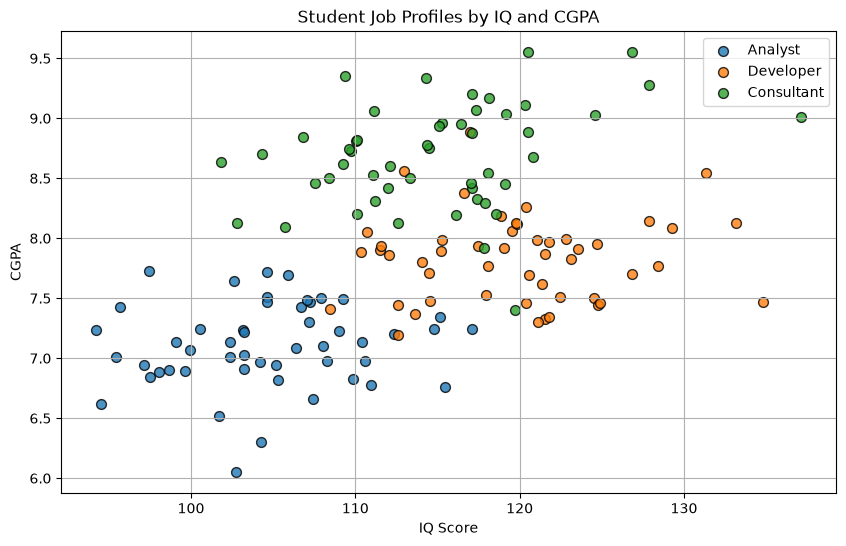

In [22]:
# scatter plot to visualize the three job profile classes
plt.figure(figsize=(10, 6))

for profile_id, profile_name in profile_names.items():
    profile_data = softmax_df[softmax_df["Job_Profile"] == profile_id]
    plt.scatter(
          profile_data["IQ"],
          profile_data["CGPA"],
          label=profile_name,
          s=50,
          edgecolor="k",
          alpha=0.8
      )

plt.xlabel("IQ Score")
plt.ylabel("CGPA")
plt.title("Student Job Profiles by IQ and CGPA")
plt.legend()
plt.grid(True)
plt.show()

The scatter plot shows three different groups. 

Softmax Regression will learn decision boundaries that separate these three classes.

In [23]:
# features columns
X_softmax = softmax_df[["IQ", "CGPA"]]

# target column with three classes
y_softmax = softmax_df["Job_Profile"]

# split the dataset into training and testing sets
X_softmax_train, X_softmax_test, y_softmax_train, y_softmax_test = train_test_split(
    X_softmax,
    y_softmax,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_softmax
)

print("Training rows:", X_softmax_train.shape[0])
print("Testing rows:", X_softmax_test.shape[0])

Training rows: 120
Testing rows: 30


In [24]:
# train Softmax Regression model
softmax_model = LogisticRegression(max_iter=1000)
softmax_model.fit(X_softmax_train, y_softmax_train)

# predict job profiles for the test set
y_softmax_pred = softmax_model.predict(X_softmax_test)

# calculate model accuracy
softmax_acc = accuracy_score(y_softmax_test, y_softmax_pred)

print(f"Softmax Regression Accuracy: {softmax_acc * 100:.2f}%")
print("Classes learned by the model:", softmax_model.classes_)

Softmax Regression Accuracy: 93.33%
Classes learned by the model: [0 1 2]


The model has learned to classify students into three job profiles. Accuracy tells us how many test examples were assigned to the correct
profile

In [25]:
# inspect predicted probabilities before final class prediction
softmax_probability_preview = pd.DataFrame(
      softmax_model.predict_proba(X_softmax_test[:5]),
      columns=[profile_names[class_id] for class_id in softmax_model.classes_],
      index=X_softmax_test[:5].index
)

print("Predicted probabilities for first five test rows:")
print(softmax_probability_preview)

print("\nFinal predicted job profiles:")
predicted_profiles = pd.Series(y_softmax_pred[:5]).map(profile_names)
print(predicted_profiles)

Predicted probabilities for first five test rows:
      Analyst  Developer  Consultant
38   0.998310   0.001457    0.000233
127  0.071829   0.110174    0.817998
57   0.007805   0.762793    0.229403
93   0.039982   0.929341    0.030676
42   0.979207   0.019775    0.001017

Final predicted job profiles:
0       Analyst
1    Consultant
2     Developer
3     Developer
4       Analyst
dtype: str


Softmax Regression gives one probability for each class. 

The final predicted class is the one with the highest probability.


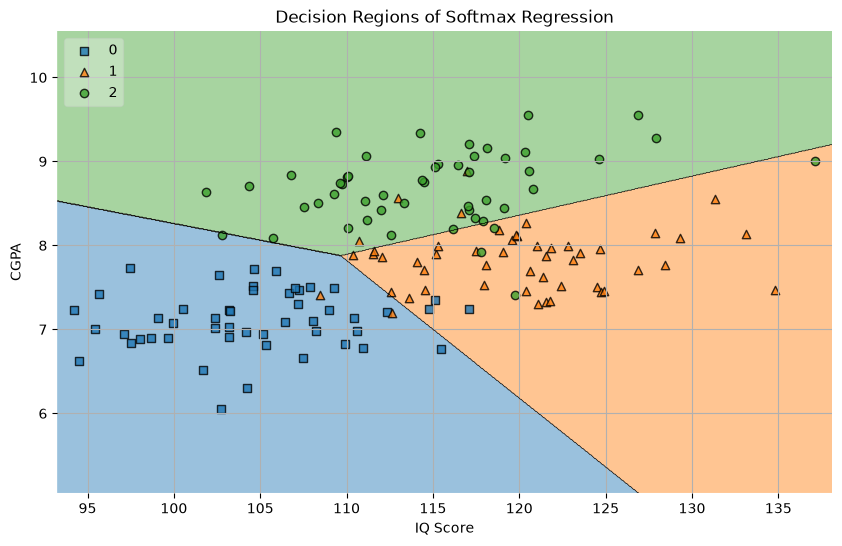

In [26]:
# train on full data only for decision-region visualization
X_softmax_np = X_softmax.values
y_softmax_np = y_softmax.values

softmax_boundary_model = LogisticRegression(max_iter=1000)
softmax_boundary_model.fit(X_softmax_np, y_softmax_np)

plt.figure(figsize=(10, 6))
plot_decision_regions(X_softmax_np, y_softmax_np, clf=softmax_boundary_model, legend=2)

plt.xlabel("IQ Score")
plt.ylabel("CGPA")
plt.title("Decision Regions of Softmax Regression")
plt.grid(True)
plt.show()

The plot shows how Softmax Regression divides the feature space into three regions. 

Each region represents the class that receives the highest predicted probability in that area.

## Chapter Recap

In this chapter, we learned the following ideas:

- Logistic Regression is used for classification, even though its name contains regression.
- The sigmoid function converts a raw score into a probability between 0 and 1.
- Log loss measures how wrong the predicted probabilities are.
- A decision boundary separates the predicted classes.
- Regularization helps Logistic Regression generalize better on high-dimensional data.
- Polynomial features can help Logistic Regression handle non-linear patterns.
- Softmax Regression extends Logistic Regression to multi-class classification.